L = 11, N = 1, dim = 11
initial state = (0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0)  (center site 5)
final norm = 0.9999999992756291


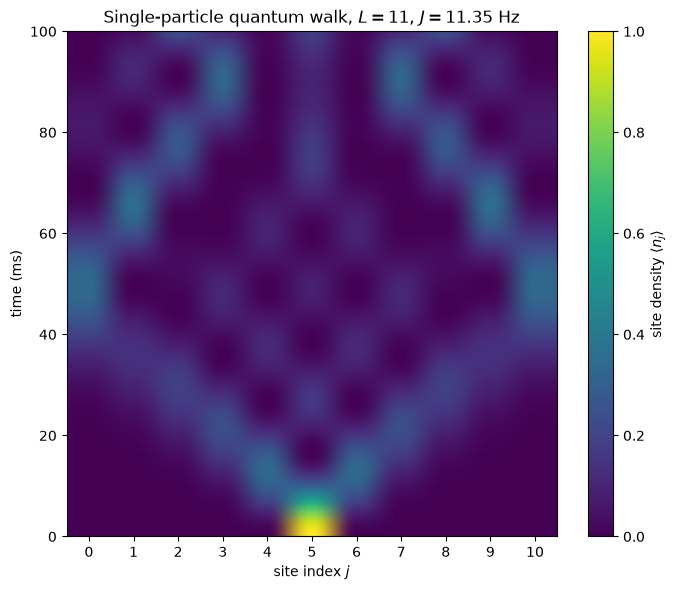

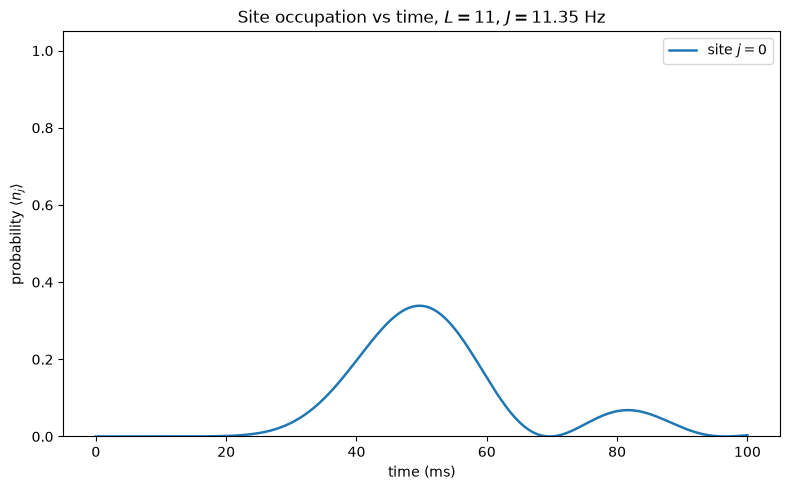

In [6]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================
# 1D single-particle tunneling experiment (quantum walk)
#   - NO Floquet drive (static J)
#   - NO tilt (Delta = 0)
#   - particle starts at the center of the chain
# =============================================================

# -----------------------------
# System
# -----------------------------
L = 11          # number of sites
N = 1          # number of particles

J_hz = 11.35    # tunneling strength (Hz)
TIME_EVOLVE = 0.1   # total evolution time (seconds)

# Line-cut option: probability (site density) vs time for specified site(s).
# Set to a list of site indices to plot, e.g. [2] or [0, 2, 4].
# Set to None (or an empty list) to skip this plot.
PLOT_SITES = [0]

twopi = 2.0 * np.pi
J = twopi * J_hz    # angular frequency (rad/s)

# -----------------------------
# Fixed-N basis (single particle -> one basis state per site)
# -----------------------------
def generate_basis(L, N):
    return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
            if sum(occ) == N]
basis = generate_basis(L, N)
index = {s: i for i, s in enumerate(basis)}
dim   = len(basis)

print("L = %d, N = %d, dim = %d" % (L, N, dim))

# -----------------------------
# Hamiltonian: nearest-neighbour hopping only (no diagonal: U irrelevant for N=1,
# Delta = 0 so no tilt). Open chain.
# -----------------------------
def build_hop():
    H = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        n = np.array(state)
        for j in range(L-1):
            if n[j] > 0:
                new = n.copy(); amp = np.sqrt(n[j])*np.sqrt(n[j+1]+1)
                new[j]-=1; new[j+1]+=1
                H[index[tuple(new)], a] += -J*amp
            if n[j+1] > 0:
                new = n.copy(); amp = np.sqrt(n[j+1])*np.sqrt(n[j]+1)
                new[j+1]-=1; new[j]+=1
                H[index[tuple(new)], a] += -J*amp
    return H

H = build_hop()

# -----------------------------
# Site-density operators n_j (diagonal in Fock basis)
# -----------------------------
n_ops = []
for site in range(L):
    op = np.zeros((dim, dim), dtype=complex)
    for a, state in enumerate(basis):
        op[a, a] = state[site]
    n_ops.append(op)

# -----------------------------
# Initial state: particle at the center site
# -----------------------------
center = L // 2                       # for L=5 -> site index 2
init_state = tuple(1 if s == center else 0 for s in range(L))
psi0 = np.zeros(dim, dtype=complex)
psi0[index[init_state]] = 1.0
print("initial state =", init_state, " (center site %d)" % center)

# -----------------------------
# Time evolution
# -----------------------------
def rhs(t, psi):
    return -1j * H.dot(psi)

n_times = 400
times = np.linspace(0.0, TIME_EVOLVE, n_times)
sol = solve_ivp(rhs, (0.0, TIME_EVOLVE), psi0, t_eval=times,
                rtol=1e-10, atol=1e-10, method="RK45")
psis = sol.y.T
print("final norm =", np.linalg.norm(psis[-1]))

# density[t, site] = <n_site>(t)
density = np.zeros((len(times), L))
for ti, p in enumerate(psis):
    for site in range(L):
        density[ti, site] = np.vdot(p, n_ops[site].dot(p)).real

# -----------------------------
# Heatmap: density vs (site, time)
# -----------------------------
times_ms = 1000.0 * times    # convert seconds -> ms

plt.figure(figsize=(7, 6))
# imshow with sites on x, time on y; origin lower so t increases upward
im = plt.imshow(density, aspect="auto", origin="lower",
                extent=[-0.5, L-0.5, times_ms[0], times_ms[-1]],
                cmap="viridis", vmin=0.0, vmax=1.0)
plt.colorbar(im, label=r"site density $\langle n_j \rangle$")
plt.xlabel("site index $j$")
plt.ylabel("time (ms)")
plt.xticks(range(L))
plt.title(r"Single-particle quantum walk, $L=%d$, $J=%.2f$ Hz" % (L, J_hz))
plt.tight_layout()
plt.savefig("test_J_0_heatmap.png", dpi=120)
plt.show()

# -----------------------------
# Line cuts: probability to be on specified site(s) vs time
# -----------------------------
if PLOT_SITES:
    plt.figure(figsize=(8, 5))
    for site in PLOT_SITES:
        if site < 0 or site >= L:
            print("warning: site %d out of range [0, %d], skipping" % (site, L-1))
            continue
        plt.plot(times_ms, density[:, site], lw=1.8,
                 label=r"site $j=%d$" % site)
    plt.xlabel("time (ms)")
    plt.ylabel(r"probability $\langle n_j \rangle$")
    plt.ylim(0, 1.05)
    plt.title(r"Site occupation vs time, $L=%d$, $J=%.2f$ Hz" % (L, J_hz))
    plt.legend()
    plt.tight_layout()
    plt.savefig("test_J_0_sites.png", dpi=120)
    plt.show()